# Module 06 Lab - Regression and Classification Models

**Objective:** To understand the difference between regression and classification and to build your first linear models for both tasks.

**In this lab, you will write the code to train and evaluate the models.**

## Part 1: Regression vs. Classification

This is the most fundamental distinction between types of supervised learning problems.

*   **Regression:** The goal is to predict a **continuous numerical value**. 
    *   *Examples:* Predicting the price of a house, the temperature tomorrow, or the stock price.

*   **Classification:** The goal is to predict a **discrete category or class label**.
    *   *Examples:* Predicting if an email is spam or not spam, if a flower is a setosa, versicolor, or virginica, or if a customer will churn or not.

**In this lab, we will tackle one of each.**

## Part 2: Linear Regression

**Concept:** Linear Regression is used to predict a continuous value. It works by finding the best-fitting straight line through the data points. The model learns a "slope" (coefficient) for each feature and an "intercept".

*   **Problem:** We will predict the `Fare` of a Titanic passenger based on their `Age` and `Pclass`.

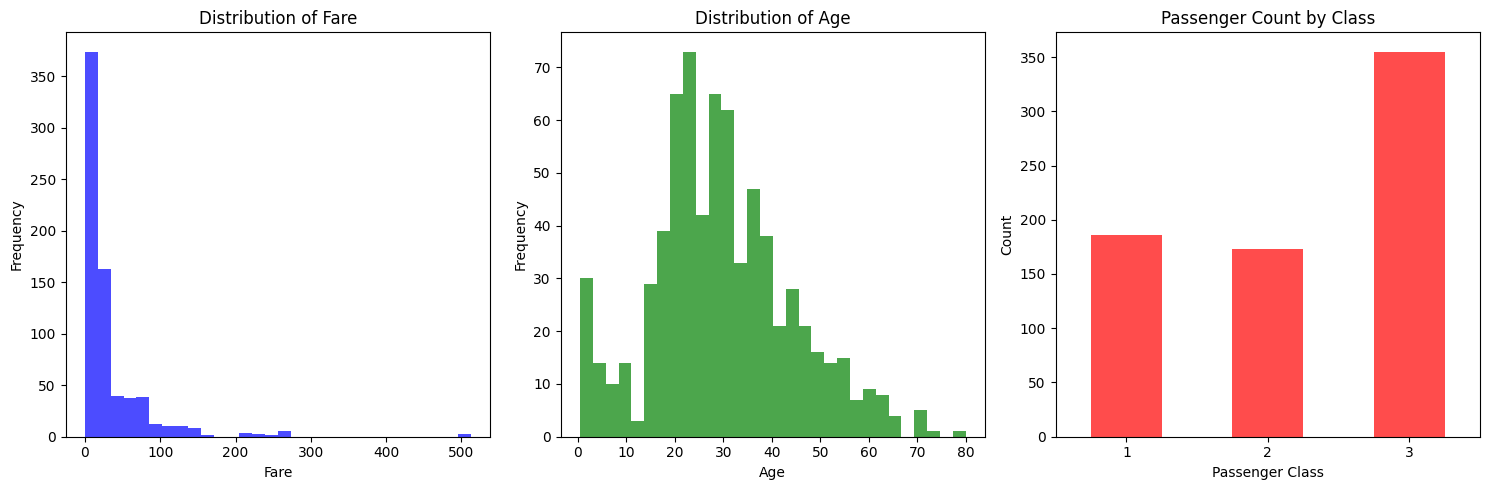

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load and prepare the data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Drop rows with missing age
df.dropna(subset=['Age'], inplace=True)

# Define features and target
features = ['Age', 'Pclass']
target_reg = 'Fare'

X_reg = df[features]
y_reg = df[target_reg]

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Start the side-by-side plotting layout
plt.figure(figsize=(15, 5))

# 1. Plot distribution of the target variable (Fare)
plt.subplot(1, 3, 1)
plt.hist(y_reg, bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

# 2. Plot distribution of Age
plt.subplot(1, 3, 2)
plt.hist(X_reg['Age'], bins=30, color='green', alpha=0.7)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# 3. Plot distribution of Pclass (The Fixed Pandas Section)
plt.subplot(1, 3, 3) # <-- Added this to activate the 3rd slot!

class_counts = df['Pclass'].value_counts().sort_index()
# Added ax=plt.gca() so Pandas draws INSIDE the 3rd slot
class_counts.plot(kind='bar', color='red', alpha=0.7, ax=plt.gca()) 

plt.title('Passenger Count by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.xticks(rotation=0) 

# Clean up and show everything together
plt.tight_layout()
plt.show()

### Task 1: Train and Evaluate a Linear Regression Model

**Your Task:**
1.  Create an instance of the `LinearRegression` model.
2.  Train the model using the training data (`X_train_reg`, `y_train_reg`).
3.  Make predictions on the test data.
4.  Evaluate the model using `mean_squared_error`. This metric tells us the average of the squared differences between the predicted and actual values.

In [28]:
import numpy as np

# 1. Create the model instance
lr_model = LinearRegression()

# 2. Train the model
lr_model.fit(X_train_reg, y_train_reg)

# 3. Make predictions
y_pred_reg = lr_model.predict(X_test_reg)

# 4. Evaluate the model
mse = mean_squared_error(y_test_reg, y_pred_reg)
print(f"Mean Squared Error for Fare Prediction: {mse:.2f}")
print(f"The square root of this is {np.sqrt(mse):.2f}, meaning our model is off by about $58 on average.")
print(f"Logistic Regression Coefficients: {lr_model.coef_}")

Mean Squared Error for Fare Prediction: 3364.92
The square root of this is 58.01, meaning our model is off by about $58 on average.
Logistic Regression Coefficients: [ -0.43695889 -38.29728935]


## Part 3: Logistic Regression

**Concept:** Despite its name, Logistic Regression is a **classification** algorithm. It works by calculating the probability that a given input belongs to a certain class. It's one of the most widely used and interpretable classification models.

*   **Problem:** We will predict whether a passenger `Survived` based on their `Age`, `Pclass`, and `Sex`.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Prepare data for classification
# We need to encode 'Sex' column
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Define features and target
features_cls = ['Age', 'Pclass', 'Sex']
target_cls = 'Survived'

X_cls = df[features_cls]
y_cls = df[target_cls]

# Split the data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

### Task 2: Train and Evaluate a Logistic Regression Model

**Your Task:**
1.  Create an instance of the `LogisticRegression` model.
2.  Train the model using the classification training data.
3.  Make predictions on the test data.
4.  Evaluate the model using `accuracy_score`.

In [30]:
# 1. Create the model instance
log_model = LogisticRegression()

# 2. Train the model
log_model.fit(X_train_cls, y_train_cls)

# 3. Make predictions
y_pred_cls = log_model.predict(X_test_cls)

# 4. Evaluate the model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy for Survival Prediction: {accuracy:.2%}")


Accuracy for Survival Prediction: 74.83%


## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

1.  **In your own words, what is the key difference between a regression problem and a classification problem?**<br>
*The difference between a regression problem and a classification problem depends on what data you're trying to get insights from. For example, are you trying to get a numerical value, something that can be measured, or are you trying to get a grouped value, something that can be categorized?*

2.  **The `LinearRegression` model has an attribute called `.coef_`. After you train the model, print `lr_model.coef_`. What do these numbers represent?**<br>
*These numbers represent the age and pclass weights for these two features. A negative number causes the target to decrease (fare). The age has a lower value than the pclass, therefore pclass has a stronger weight on the probablitiy that the far decreases.*

3.  **Why did we use `mean_squared_error` to evaluate the regression model but `accuracy_score` for the classification model?** Why wouldn't accuracy be a good metric for the fare prediction task?<br>
*We use MSE on regression models because the predictions can be any number of values, and instead of tallying up correct/incorrect (there would be too many incorrect and it would be almost impossible to get the correct prediction in any feasible time frame), we calculate the MSE (how far off the prediction was) instead. We use AS for the classification model for classification since the predictions usuallly fall into two categories (survived vs did not survive) so it's simple to calculate the accuracy since there is two values it can be.*
